# 02 — Modélisation : Baselines + Optuna + MLflow

**Objectif :** entraîner et comparer plusieurs modèles de classification (LR, NB, SGD, LinearSVC, XGBoost), optimiser **tous** les modèles avec Optuna, et tracker chaque expérience avec MLflow.

| Étape | Contenu |
|---|---|
| Baselines | LR, NB, SGD, LinearSVC — paramètres par défaut |
| Optimisation | Optuna sur **chaque** modèle (LR, NB, SGD, LinearSVC, XGBoost) |
| Évaluation finale | Meilleur modèle sur le test set (touché une seule fois) |
| Tracking | MLflow — chaque run loggé automatiquement |
| Métrique principale | **F1-macro** (classes déséquilibrées 81/19 %) |

## 0. Imports globaux

### Description de l'étape

Chargement de toutes les librairies nécessaires et configuration du path projet.
MLflow et Optuna sont importés ici mais configurés dans leurs sections dédiées.

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

import mlflow
import mlflow.sklearn
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import (
    f1_score, classification_report,
    ConfusionMatrixDisplay, accuracy_score
)
from xgboost import XGBClassifier
import dill

# ── Path projet ───────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
sys.path.insert(0, str(PROJECT_ROOT))

from settings.params import (
    TARGET_COL, STEMMED_COL, FEATURES_ALL, FEATURES_LINEAR,
    TFIDF_NGRAM_RANGE, TFIDF_MAX_FEATURES, TFIDF_MIN_DF, TFIDF_SUBLINEAR_TF,
    PRIMARY_METRIC, RANDOM_STATE,
)
from src.utils.config import cfg
from src.utils.logger import logger

logger.info("Imports OK")

2026-06-06 18:52:57 | INFO | __main__ | Imports OK


### Analyse & Interprétation

Tous les imports sont chargés. Le path projet est résolu dynamiquement depuis le dossier `notebooks/` — fonctionne quel que soit le poste de travail.

## 1. Chargement des données

### Description de l'étape

Chargement des trois splits produits par le notebook `01-02`. Les fichiers `.parquet` préservent les types exacts (bool, StringDtype, float64). On ne retouche plus les données ici — tout le preprocessing est déjà appliqué.

In [2]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

df_train = pd.read_parquet(PROCESSED_DIR / "train.parquet")
df_val   = pd.read_parquet(PROCESSED_DIR / "val.parquet")
df_test  = pd.read_parquet(PROCESSED_DIR / "test.parquet")

for name, df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    rate = df[TARGET_COL].mean()
    logger.info(f"{name:5} | shape={df.shape} | disaster_rate={rate:.3f}")

df_train.head(3)

2026-06-06 18:53:03 | INFO | __main__ | Train | shape=(7959, 25) | disaster_rate=0.186
2026-06-06 18:53:03 | INFO | __main__ | Val   | shape=(1705, 25) | disaster_rate=0.186
2026-06-06 18:53:03 | INFO | __main__ | Test  | shape=(1706, 25) | disaster_rate=0.186


,id,keyword,location,text,target,label,text_length,word_count,avg_word_length,has_url,...,has_location,clean_text,tokens,token_count,unique_tokens,ttr,preprocessed_text,preprocessed_len,compression_ratio,kw_disaster_rate
0,11300,wreckage,<NA>,"""Barr, a conservative Catholic, blamed spread ...",False,Not Disaster,124.0,20.0,5.25,0,...,0,barr a conservative catholic blamed spread of ...,barr conservative catholic blamed spread secul...,12.0,12.0,1.0,barr conserv cathol blame spread secular moral...,12.0,0.600,0.316
1,922,blazing,"Barling, AR.","""I swear on my dear mothers gravewell, I would...",False,Not Disaster,132.0,24.0,4.54,1,...,1,i swear on my dear mothers gravewell i would d...,swear dear mother gravewell onethat wasnt goin...,9.0,9.0,1.0,swear dear mother gravewel would onethat wasnt...,10.0,0.417,0.000
2,3473,demolished,"Auckland Park, Johannesburg",We saw lots of litter around Ushaka beach (alb...,False,Not Disaster,109.0,16.0,5.88,1,...,1,we saw lots of litter around ushaka beach albe...,saw lot litter around ushaka beach albeit heav...,10.0,10.0,1.0,saw lot litter around ushaka beach albeit heav...,10.0,0.625,0.098


### Analyse & Interprétation

**Statistiques des splits :**

| Split | Lignes | Colonnes | Disaster rate |
|-------|--------|----------|---------------|
| Train | 7 959  | 25       | 0.186         |
| Val   | 1 705  | 25       | 0.186         |
| Test  | 1 706  | 25       | 0.186         |

**Total : 7 959 + 1 705 + 1 706 = 11 370 tweets** (dataset labellisé Kaggle), split 70/15/15.

**Structure des données (25 colonnes) :**
- 6 colonnes brutes : `id`, `keyword`, `location`, `text`, `target`, `label`
- 3 colonnes textuelles prétraitées : `clean_text`, `tokens`, `preprocessed_text`
- 16 features engineerées numériques : `text_length`, `word_count`, `ttr`, `kw_disaster_rate`…

**Validation de la stratification :**
Le disaster_rate est identique dans les 3 splits (0.186) — la stratification appliquée dans `01-02` est parfaitement respectée. Le déséquilibre 81/19 % est préservé uniformément dans train, val et test.

**Observations sur le `head(3)` :**
- `ttr = 1.0` pour les 3 lignes → tous les tokens sont uniques dans ces tweets courts (richesse lexicale maximale)
- `kw_disaster_rate` varie par keyword : `wreckage`=0.316, `blazing`=0.000, `demolished`=0.098 — `blazing`=0.000 signifie qu'aucun tweet avec ce keyword dans le split train n'est labelisé disaster. Cette valeur est calculée sur train uniquement (anti-leakage) — c'est une statistique locale au train, pas une propriété absolue du mot.
- `compression_ratio` entre 0.42 et 0.63 → le stemming réduit le texte d'environ 40-60%
- Les 3 lignes affichées sont `Not Disaster` — cohérent avec la classe majoritaire (81%)

**Conclusion :** Données correctement chargées, types préservés, toutes les 25 features attendues sont présentes. Prêt pour la construction des matrices.

## 2. Construction des matrices de features

### Description de l'étape

Quatre matrices construites selon les **recommandations de l'EDA** :

**TF-IDF** (`ngram_range=(1,2)`, `max_features=10 000`, `min_df=3`) — représentation principale pour tous les modèles :
- Les **bigrams** capturent des expressions composées discriminantes (`suicide bomber`, `flash flood`).
- `min_df=3` filtre les hapax. `max_features=10 000` limite la dimensionnalité.

**Features numériques — deux ensembles distincts (recommandation EDA) :**
- `FEATURES_LINEAR` (7 features) → LR, SGD, LinearSVC : sans `word_count`, `token_count` (colinéaires avec `text_length`).
- `FEATURES_ALL` (16 features) → XGBoost : toutes les features conservées, les arbres gèrent la redondance.

**Matrices combinées par modèle :**
- **LR / SGD / LinearSVC** : TF-IDF + `FEATURES_LINEAR` scalées (`MaxAbsScaler`)
- **NB** : TF-IDF seul (MultinomialNB exige des valeurs ≥ 0)
- **XGBoost** : TF-IDF + `FEATURES_ALL` brutes (pas de scaling — les arbres n'en ont pas besoin)

`MaxAbsScaler` préserve les matrices creuses (sparse). TF-IDF **fitté sur train uniquement** — pas de fuite de données.

In [3]:
# ── Targets ───────────────────────────────────────────────────────────────────
y_train = df_train[TARGET_COL].astype(int).values
y_val   = df_val[TARGET_COL].astype(int).values
y_test  = df_test[TARGET_COL].astype(int).values

# ── TF-IDF (fitté sur train uniquement) ──────────────────────────────────────
tfidf = TfidfVectorizer(
    ngram_range=TFIDF_NGRAM_RANGE,
    max_features=TFIDF_MAX_FEATURES,
    min_df=TFIDF_MIN_DF,
    sublinear_tf=TFIDF_SUBLINEAR_TF,
)
X_train_tfidf = tfidf.fit_transform(df_train[STEMMED_COL])
X_val_tfidf   = tfidf.transform(df_val[STEMMED_COL])
X_test_tfidf  = tfidf.transform(df_test[STEMMED_COL])

# ── Features numériques linéaires — LR / SGD / LinearSVC ─────────────────────
# FEATURES_LINEAR exclut word_count et token_count (colinéaires avec text_length)
scaler = MaxAbsScaler()
X_train_num = scaler.fit_transform(df_train[FEATURES_LINEAR].fillna(0))
X_val_num   = scaler.transform(df_val[FEATURES_LINEAR].fillna(0))
X_test_num  = scaler.transform(df_test[FEATURES_LINEAR].fillna(0))

# ── Matrices combinées : TF-IDF + numériques linéaires (LR / SGD / LinearSVC) ─
X_train_comb = hstack([X_train_tfidf, csr_matrix(X_train_num)])
X_val_comb   = hstack([X_val_tfidf,   csr_matrix(X_val_num)])
X_test_comb  = hstack([X_test_tfidf,  csr_matrix(X_test_num)])

# ── Features numériques complètes — XGBoost (toutes les 16 features) ──────────
# .astype(float) nécessaire car certaines colonnes sont en dtype object après parquet
X_train_xgb_num = df_train[FEATURES_ALL].fillna(0).astype(float).values
X_val_xgb_num   = df_val[FEATURES_ALL].fillna(0).astype(float).values
X_test_xgb_num  = df_test[FEATURES_ALL].fillna(0).astype(float).values

# ── Matrices combinées XGBoost : TF-IDF + toutes les features numériques ──────
# Recommandation EDA : TF-IDF (représentation principale) + FEATURES_ALL
X_train_xgb = hstack([X_train_tfidf, csr_matrix(X_train_xgb_num)])
X_val_xgb   = hstack([X_val_tfidf,   csr_matrix(X_val_xgb_num)])
X_test_xgb  = hstack([X_test_tfidf,  csr_matrix(X_test_xgb_num)])

# ── Poids de déséquilibre pour XGBoost ────────────────────────────────────────
# Ratio majority/minority ≈ 4.38 — calculé sur train uniquement
scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())

print(f"TF-IDF seul               : {X_train_tfidf.shape}")
print(f"Combiné LR/SGD/SVC        : {X_train_comb.shape}")
print(f"Combiné XGBoost (TF+num)  : {X_train_xgb.shape}")
print(f"scale_pos_weight          : {scale_pos_weight:.3f}")

TF-IDF seul               : (7959, 5590)
Combiné LR/SGD/SVC        : (7959, 5597)
Combiné XGBoost (TF+num)  : (7959, 5606)
scale_pos_weight          : 4.378


### Analyse & Interprétation

**Dimensions des matrices (train) :**

| Matrice | Shape | Utilisée par |
|---------|-------|--------------|
| TF-IDF seul | (7 959, **5 590**) | NB |
| Combinée LR/SGD/SVC (TF-IDF + 7 num) | (7 959, **5 597**) | LR, SGD, LinearSVC |
| Combinée XGBoost (TF-IDF + 16 num) | (7 959, **5 606**) | XGBoost |
| scale_pos_weight | **4.378** | XGBoost |

**Vérification des dimensions :**
- 5 590 + 7 (FEATURES_LINEAR) = **5 597** ✓
- 5 590 + 16 (FEATURES_ALL) = **5 606** ✓

**Observation importante — TF-IDF : 5 590 termes au lieu de 10 000 :**
`max_features=10 000` est un plafond, pas une valeur fixe. Avec `min_df=3`, seuls les termes apparaissant dans au moins 3 tweets sont conservés. Le vocabulaire réel ne contient que **5 590 termes** — le dataset est relativement petit (11 370 tweets) et le vocabulaire après stemming est limité.

**Validation des choix EDA :**
- `FEATURES_LINEAR` = 7 features (sans `word_count`, `token_count`) → multicolinéarité évitée pour LR/SGD/SVC ✓
- `FEATURES_ALL` = 16 features pour XGBoost → redondance tolérée par les arbres ✓
- `ngram_range=(1,2)` → bigrams validés par l'EDA sur tweets courts ✓
- `min_df=3` → hapax filtrés, vocabulaire réduit de ~44% par rapport au plafond ✓
- `scale_pos_weight=4.378` ≈ ratio 81/19% — gestion du déséquilibre pour XGBoost ✓
- `sublinear_tf=True` → répétitions émotionnelles lissées, vecteurs plus équilibrés sur tweets courts ✓
- **TF-IDF utilisé pour tous les modèles** (représentation principale recommandée par l'EDA) ✓

**Conclusion :** Les matrices sont construites sans fuite de données (fit sur train uniquement). Toutes les matrices sont sparse — efficaces en mémoire. XGBoost bénéficie maintenant du signal textuel TF-IDF en plus des features numériques, conformément aux recommandations EDA.

## 3. Configuration MLflow

### Description de l'étape

Initialisation de MLflow. Toutes les runs sont stockées dans `mlflow/` à la racine du projet. Chaque modèle entraîné aura sa propre run avec paramètres, métriques et artefact sauvegardés. Pour visualiser : `make mlflow-ui` depuis la racine.

In [4]:
MLFLOW_DIR = PROJECT_ROOT / "mlflow"
MLFLOW_DIR.mkdir(exist_ok=True)

mlflow.set_tracking_uri(f"file://{MLFLOW_DIR}")
mlflow.set_experiment(cfg["mlflow"]["experiment_name"])

logger.info(f"Experiment : {cfg['mlflow']['experiment_name']}")
logger.info(f"Tracking   : {mlflow.get_tracking_uri()}")

2026-06-06 18:53:22 | INFO | __main__ | Experiment : disaster-tweet-classifier
2026-06-06 18:53:22 | INFO | __main__ | Tracking   : file:///Users/macbookpro/Desktop/DIC3/mlops/projet/projet_mlops/NLP_Disaster_Tweets-/mlflow


## 4. Fonctions utilitaires

### Description de l'étape

`train_and_log` centralise l'entraînement, l'évaluation sur val et le logging MLflow. Tous les résultats sont également stockés dans la liste `results` pour la comparaison finale.

In [5]:
results = []

def train_and_log(model, X_tr, y_tr, X_val, y_val,
                  name: str, params: dict = None, tags: dict = None) -> dict:
    """Entraîne, évalue sur val, logue dans MLflow et retourne les métriques."""
    with mlflow.start_run(run_name=name):
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        metrics = {
            "model":     name,
            "f1_macro":  round(f1_score(y_val, y_pred, average="macro"), 4),
            "f1_class0": round(f1_score(y_val, y_pred, pos_label=0), 4),
            "f1_class1": round(f1_score(y_val, y_pred, pos_label=1), 4),
            "accuracy":  round(accuracy_score(y_val, y_pred), 4),
        }

        mlflow.log_params(params or {})
        mlflow.log_metrics({k: v for k, v in metrics.items() if k != "model"})
        if tags:
            mlflow.set_tags(tags)
        mlflow.sklearn.log_model(model, "model")

    results.append(metrics)
    logger.info(f"{name:25} | F1-macro={metrics['f1_macro']:.4f} | acc={metrics['accuracy']:.4f}")
    return metrics

## 5. Baselines (paramètres par défaut)

### 5.1 Logistic Regression

### Description de l'étape

LR + TF-IDF + features numériques linéaires. `class_weight='balanced'` compense le déséquilibre 81/19 % en pondérant automatiquement la classe minoritaire (Real Disaster) inversement à sa fréquence.

In [6]:
lr_params = {"C": 1.0, "max_iter": 1000, "solver": "lbfgs"}
lr = LogisticRegression(**lr_params, class_weight="balanced", random_state=RANDOM_STATE)

metrics_lr = train_and_log(
    lr, X_train_comb, y_train, X_val_comb, y_val,
    name="LR_baseline", params=lr_params,
    tags={"phase": "baseline", "features": "tfidf+num_linear"}
)
print(classification_report(y_val, lr.predict(X_val_comb),
                             target_names=["Not Disaster", "Real Disaster"]))

2026/06/06 18:53:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 18:53:39 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026-06-06 18:53:39 | INFO | __main__ | LR_baseline               | F1-macro=0.7541 | acc=0.8270


               precision    recall  f1-score   support

 Not Disaster       0.94      0.84      0.89      1388
Real Disaster       0.52      0.76      0.62       317

     accuracy                           0.83      1705
    macro avg       0.73      0.80      0.75      1705
 weighted avg       0.86      0.83      0.84      1705



### Analyse & Interprétation

**Avertissements MLflow (non bloquants) :**
- `artifact_path is deprecated` → warning interne MLflow, aucun impact sur les résultats
- `Model logged without a signature` → modèle bien sauvegardé, juste sans schéma d'entrée défini

**Résultats LR Baseline — Val set :**

| Métrique | Not Disaster | Real Disaster |
|----------|-------------|---------------|
| Précision | 0.94 | 0.52 |
| Rappel | 0.84 | 0.76 |
| F1-score | 0.89 | 0.62 |
| Support | 1 388 | 317 |

**F1-macro = 0.7541 | Accuracy = 0.8270**

**Cohérence :**
- Support : 1 388/1 705 = 81.4% et 317/1 705 = 18.6% → déséquilibre attendu ✓
- F1-macro = (0.89 + 0.62) / 2 = 0.755 ≈ 0.7541 ✓

**Analyse par classe :**

*Not Disaster (classe majoritaire) :*
- Précision 0.94 → 94% des tweets prédits "Not Disaster" sont corrects
- Rappel 0.84 → le modèle retrouve 84% de tous les vrais "Not Disaster"
- F1 = 0.89 → très bon, classe facile à apprendre (beaucoup d'exemples)

*Real Disaster (classe minoritaire) :*
- Précision 0.52 → seulement 52% des tweets prédits "Real Disaster" sont corrects (beaucoup de faux positifs)
- Rappel 0.76 → le modèle détecte 76% des vrais tweets de catastrophe
- F1 = 0.62 → plus faible, classe difficile (18.6% des données seulement)

**Interprétation :**
`class_weight='balanced'` a boosté le rappel de Real Disaster (0.76) au détriment de la précision (0.52) — le modèle préfère sur-prédire "Real Disaster" plutôt que de le manquer. Ce compromis est acceptable : manquer une vraie catastrophe est plus coûteux qu'un faux positif.

**Conclusion :** F1-macro = 0.7541 est notre référence baseline. C'est un bon point de départ — Optuna devrait améliorer ce score en optimisant C, solver et max_iter.

### 5.2 Naive Bayes

### Description de l'étape

MultinomialNB sur TF-IDF uniquement. NB suppose que toutes les features sont indépendantes (hypothèse naïve) et exige des valeurs ≥ 0. Sert de **plancher de référence** : tout modèle doit faire mieux.

In [7]:
nb_params = {"alpha": 1.0}
nb = MultinomialNB(**nb_params)

metrics_nb = train_and_log(
    nb, X_train_tfidf, y_train, X_val_tfidf, y_val,
    name="NB_baseline", params=nb_params,
    tags={"phase": "baseline", "features": "tfidf_only"}
)
print(classification_report(y_val, nb.predict(X_val_tfidf),
                             target_names=["Not Disaster", "Real Disaster"]))

2026/06/06 18:54:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 18:54:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026-06-06 18:54:14 | INFO | __main__ | NB_baseline               | F1-macro=0.7182 | acc=0.8733


               precision    recall  f1-score   support

 Not Disaster       0.87      0.99      0.93      1388
Real Disaster       0.91      0.35      0.51       317

     accuracy                           0.87      1705
    macro avg       0.89      0.67      0.72      1705
 weighted avg       0.88      0.87      0.85      1705



### Analyse & Interprétation

**Résultats NB Baseline — Val set :**

| Métrique | Not Disaster | Real Disaster |
|----------|-------------|---------------|
| Précision | 0.87 | 0.91 |
| Rappel | 0.99 | 0.35 |
| F1-score | 0.93 | 0.51 |
| Support | 1 388 | 317 |

**F1-macro = 0.7182 | Accuracy = 0.8733**

**Observation clé — le paradoxe accuracy/F1-macro :**
NB a une accuracy plus élevée que LR (0.87 vs 0.83) mais un F1-macro plus faible (0.72 vs 0.75). C'est exactement pourquoi on utilise le F1-macro sur des données déséquilibrées — l'accuracy est trompeuse ici.

**Analyse par classe :**

*Not Disaster :*
- Rappel 0.99 → le modèle prédit "Not Disaster" pour presque tout → classe majoritaire sur-représentée
- F1 = 0.93 → excellent, mais artificiellement gonflé par le biais vers la classe majoritaire

*Real Disaster :*
- Précision 0.91 → quand NB dit "Real Disaster", il a raison 91% du temps
- Rappel 0.35 → mais il ne détecte que **35% des vrais tweets disaster** — il en manque 65%
- F1 = 0.51 → très faible, le modèle est inutilisable pour détecter les catastrophes

**Pourquoi ce comportement ?**
Sans `class_weight='balanced'`, NB apprend que P(Not Disaster) = 0.81 — il a donc une forte tendance à prédire "Not Disaster" par défaut. Résultat : très bon rappel sur la classe majoritaire, rappel catastrophique sur la minoritaire.

**Comparaison avec LR baseline :**

| Modèle | F1-macro | F1 Real Disaster | Rappel Real Disaster |
|--------|---------|-----------------|---------------------|
| LR_baseline | **0.7541** | **0.62** | **0.76** |
| NB_baseline | 0.7182 | 0.51 | 0.35 |

LR est meilleur sur tous les indicateurs qui comptent. NB confirme son rôle de **plancher de référence**.

**Conclusion :** NB est le moins bon des baselines comme attendu. Manquer 65% des vraies catastrophes est inacceptable — Optuna tentera d'améliorer via `alpha` et `fit_prior`, mais la marge est limitée car le problème vient structurellement de l'absence de gestion du déséquilibre.

### 5.3 SGD Classifier

### Description de l'étape

SGDClassifier avec `loss='modified_huber'` — descente de gradient stochastique. Ce n'est pas un modèle à part : selon le `loss`, il simule une LR (`log_loss`) ou un SVM (`hinge`). `modified_huber` est un compromis robuste entre les deux, adapté au texte.

In [8]:
sgd_params = {"loss": "modified_huber", "alpha": 1e-4, "max_iter": 1000, "penalty": "l2"}
sgd = SGDClassifier(**sgd_params, class_weight="balanced", random_state=RANDOM_STATE)

metrics_sgd = train_and_log(
    sgd, X_train_comb, y_train, X_val_comb, y_val,
    name="SGD_baseline", params=sgd_params,
    tags={"phase": "baseline", "features": "tfidf+num_linear"}
)
print(classification_report(y_val, sgd.predict(X_val_comb),
                             target_names=["Not Disaster", "Real Disaster"]))

2026/06/06 18:54:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 18:54:40 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026-06-06 18:54:40 | INFO | __main__ | SGD_baseline              | F1-macro=0.7786 | acc=0.8663


               precision    recall  f1-score   support

 Not Disaster       0.92      0.92      0.92      1388
Real Disaster       0.64      0.64      0.64       317

     accuracy                           0.87      1705
    macro avg       0.78      0.78      0.78      1705
 weighted avg       0.87      0.87      0.87      1705



### Analyse & Interprétation

**Résultats SGD Baseline — Val set :**

| Métrique | Not Disaster | Real Disaster |
|----------|-------------|---------------|
| Précision | 0.92 | 0.64 |
| Rappel | 0.92 | 0.64 |
| F1-score | 0.92 | 0.64 |
| Support | 1 388 | 317 |

**F1-macro = 0.7786 | Accuracy = 0.8663**

**Observation clé — précision = rappel pour les deux classes :**
SGD avec `modified_huber` + `class_weight='balanced'` crée une frontière de décision plus symétrique que LR. Précision = rappel = F1 = 0.64 pour Real Disaster, et 0.92 pour Not Disaster — le modèle est calibré de façon équilibrée sur chaque classe.

**Analyse par classe :**

*Not Disaster :*
- Précision = Rappel = 0.92 → le modèle est précis et ne rate presque rien sur la classe majoritaire
- F1 = 0.92 → excellent

*Real Disaster :*
- Rappel 0.64 → détecte 64% des vrais tweets disaster (vs 76% pour LR et 35% pour NB)
- Précision 0.64 → 64% des tweets prédits "Real Disaster" sont corrects (vs 52% pour LR)
- F1 = 0.64 → meilleur que LR (0.62) et largement meilleur que NB (0.51)

**Comparaison des 3 baselines :**

| Modèle | F1-macro | F1 Real Disaster | Rappel Real Disaster | Précision Real Disaster |
|--------|---------|-----------------|---------------------|------------------------|
| LR_baseline | 0.7541 | 0.62 | 0.76 | 0.52 |
| NB_baseline | 0.7182 | 0.51 | 0.35 | 0.91 |
| **SGD_baseline** | **0.7786** | **0.64** | **0.64** | **0.64** |

SGD dépasse LR baseline (+0.0245 de F1-macro) — résultat surprenant pour un modèle "simple". La combinaison `modified_huber` + `class_weight='balanced'` offre un meilleur compromis précision/rappel que LR avec les mêmes paramètres par défaut.

**Conclusion :** SGD est le meilleur baseline jusqu'ici. Son comportement symétrique (précision ≈ rappel) est idéal pour une détection équilibrée. Optuna devrait encore améliorer ce score en explorant `loss`, `alpha`, `penalty`.

### 5.4 LinearSVC

### Description de l'étape

SVM linéaire — généralement le plus performant sur du texte TF-IDF. Maximise la marge entre les deux classes. `C` contrôle le compromis biais/variance : petit C = grande marge (plus régularisé).

In [9]:
svc_params = {"C": 1.0, "max_iter": 2000}
svc = LinearSVC(**svc_params, class_weight="balanced", random_state=RANDOM_STATE)

metrics_svc = train_and_log(
    svc, X_train_comb, y_train, X_val_comb, y_val,
    name="LinearSVC_baseline", params=svc_params,
    tags={"phase": "baseline", "features": "tfidf+num_linear"}
)
print(classification_report(y_val, svc.predict(X_val_comb),
                             target_names=["Not Disaster", "Real Disaster"]))

2026/06/06 18:54:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 18:54:52 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026-06-06 18:54:52 | INFO | __main__ | LinearSVC_baseline        | F1-macro=0.7769 | acc=0.8510


               precision    recall  f1-score   support

 Not Disaster       0.94      0.88      0.91      1388
Real Disaster       0.58      0.74      0.65       317

     accuracy                           0.85      1705
    macro avg       0.76      0.81      0.78      1705
 weighted avg       0.87      0.85      0.86      1705



### Analyse & Interprétation

**Résultats LinearSVC Baseline — Val set :**

| Métrique | Not Disaster | Real Disaster |
|----------|-------------|---------------|
| Précision | 0.94 | 0.58 |
| Rappel | 0.88 | 0.74 |
| F1-score | 0.91 | 0.65 |
| Support | 1 388 | 317 |

**F1-macro = 0.7769 | Accuracy = 0.8510**

**Analyse par classe :**

*Not Disaster :*
- Précision 0.94 → identique à LR, très fiable
- Rappel 0.88 → légèrement meilleur que LR (0.84)

*Real Disaster :*
- Rappel 0.74 → détecte 74% des vrais tweets disaster (proche de LR=0.76)
- Précision 0.58 → meilleur que LR (0.52)
- F1 = 0.65 → meilleur que LR (0.62)

**Comparaison des 4 baselines :**

| Modèle | F1-macro | F1 Real Disaster | Rappel Real Disaster |
|--------|---------|-----------------|---------------------|
| LR_baseline | 0.7541 | 0.62 | 0.76 |
| NB_baseline | 0.7182 | 0.51 | 0.35 |
| **SGD_baseline** | **0.7786** | 0.64 | 0.64 |
| LinearSVC_baseline | 0.7769 | **0.65** | 0.74 |

LinearSVC et SGD sont quasi-identiques en F1-macro (écart de 0.002). LinearSVC a un meilleur F1 Real Disaster (0.65 vs 0.64) mais SGD reste légèrement devant en F1-macro. Les deux dépassent largement LR et NB.

**Conclusion :** LinearSVC confirme la théorie — SVM linéaire est généralement le plus fort sur TF-IDF. Il est au coude-à-coude avec SGD. Optuna devrait les départager en optimisant `C`.

### 5.5 XGBoost

### Description de l'étape

XGBoost baseline sur **TF-IDF + toutes les 16 features numériques** (`FEATURES_ALL`), conformément à la recommandation EDA (synthèse section 9 : TF-IDF comme représentation principale + toutes les features pour XGBoost). `scale_pos_weight` gère le déséquilibre des classes (ratio ≈ 4.38, calculé en section 2). Pas de scaling des features numériques — les arbres de décision sont insensibles à l'échelle.

In [10]:
xgb_params = {"n_estimators": 100, "max_depth": 6, "learning_rate": 0.3}
xgb = XGBClassifier(
    **xgb_params,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric="logloss",
    verbosity=0,
    random_state=RANDOM_STATE,
)

metrics_xgb = train_and_log(
    xgb, X_train_xgb, y_train, X_val_xgb, y_val,
    name="XGBoost_baseline", params=xgb_params,
    tags={"phase": "baseline", "features": "num_all"}
)
print(classification_report(y_val, xgb.predict(X_val_xgb),
                             target_names=["Not Disaster", "Real Disaster"]))

2026/06/06 18:55:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 18:55:16 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026-06-06 18:55:16 | INFO | __main__ | XGBoost_baseline          | F1-macro=0.7454 | acc=0.8258


               precision    recall  f1-score   support

 Not Disaster       0.93      0.85      0.89      1388
Real Disaster       0.52      0.71      0.60       317

     accuracy                           0.83      1705
    macro avg       0.73      0.78      0.75      1705
 weighted avg       0.85      0.83      0.84      1705



### Analyse & Interprétation

**Résultats XGBoost Baseline — Val set (TF-IDF + FEATURES_ALL) :**

| Métrique | Not Disaster | Real Disaster |
|----------|-------------|---------------|
| Précision | 0.93 | 0.52 |
| Rappel | 0.85 | 0.71 |
| F1-score | 0.89 | 0.60 |
| Support | 1 388 | 317 |

**F1-macro = 0.7454 | Accuracy = 0.8258**

**Gain vs ancienne version (features numériques seules) :**

| Version | F1-macro | F1 Real Disaster | Rappel Real Disaster |
|---------|---------|-----------------|---------------------|
| Ancienne (num seul) | 0.7014 | 0.53 | 0.63 |
| **Nouvelle (TF-IDF + num)** | **0.7454** | **0.60** | **0.71** |

+0.044 de F1-macro — gain significatif. L'ajout du TF-IDF apporte le signal lexical manquant et confirme que la correction était nécessaire pour respecter les recommandations EDA.

**Classement des 5 baselines :**

| Modèle | F1-macro | Features |
|--------|---------|---------|
| SGD_baseline | **0.7786** | TF-IDF + 7 num |
| LinearSVC_baseline | 0.7769 | TF-IDF + 7 num |
| LR_baseline | 0.7541 | TF-IDF + 7 num |
| **XGBoost_baseline** | **0.7454** | TF-IDF + 16 num |
| NB_baseline | 0.7182 | TF-IDF seul |

XGBoost passe de dernier à **4ème** — cohérent avec les projections EDA (0.78–0.82 après Optuna).

**Analyse par classe :**

*Not Disaster :*
- Précision 0.93, Rappel 0.85 → très bon, similaire à LR

*Real Disaster :*
- Rappel 0.71 → détecte 71% des vrais tweets disaster (meilleur que LR=0.76 ? Non — 0.71 < 0.76)
- Précision 0.52 → identique à LR baseline
- F1 = 0.60 → proche de LR (0.62)

**Pourquoi XGBoost reste en dessous des modèles linéaires ?**
Les modèles linéaires (LR, SGD, SVC) sont nativement optimisés pour les matrices TF-IDF sparse haute dimension. XGBoost avec 5 606 features sparse nécessite plus de trees et un tuning plus fin — Optuna avec 50 trials devrait combler cet écart.

**Conclusion :** XGBoost corrigé est désormais aligné avec les recommandations EDA. La cible 0.78–0.82 après Optuna est atteignable.

## 6. Comparaison des baselines

### Description de l'étape

Tableau récapitulatif et visualisation des 5 baselines (LR, NB, SGD, LinearSVC, XGBoost) avant l'optimisation Optuna. Permet d'identifier les tendances et de mesurer le gain apporté par Optuna sur chaque modèle.

In [11]:
df_baselines = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
display(df_baselines)

fig = px.bar(
    df_baselines.melt(id_vars="model",
                      value_vars=["f1_macro", "f1_class0", "f1_class1", "accuracy"]),
    x="model", y="value", color="variable", barmode="group",
    title="Comparaison des baselines — Val set",
    labels={"value": "Score", "variable": "Métrique", "model": "Modèle"}
)
fig.update_layout(yaxis_range=[0.4, 1.0])
fig.show()

,model,f1_macro,f1_class0,f1_class1,accuracy
2,SGD_baseline,0.7786,0.9179,0.6392,0.8663
3,LinearSVC_baseline,0.7769,0.9055,0.6482,0.8510
0,LR_baseline,0.7541,0.8880,0.6203,0.8270
4,XGBoost_baseline,0.7454,0.8885,0.6024,0.8258
1,NB_baseline,0.7182,0.9273,0.5091,0.8733


### Analyse & Interprétation

**Classement final des 5 baselines — Val set :**

| Rang | Modèle | F1-macro | F1 Not Disaster | F1 Real Disaster | Accuracy |
|------|--------|---------|----------------|-----------------|---------|
| 1 | **SGD_baseline** | **0.7786** | 0.9179 | 0.6392 | 0.8663 |
| 2 | LinearSVC_baseline | 0.7769 | 0.9055 | **0.6482** | 0.8510 |
| 3 | LR_baseline | 0.7541 | 0.8880 | 0.6203 | 0.8270 |
| 4 | XGBoost_baseline | 0.7454 | 0.8885 | 0.6024 | 0.8258 |
| 5 | NB_baseline | 0.7182 | **0.9273** | 0.5091 | **0.8733** |

**Observations clés :**

**1. SGD et LinearSVC dominent (écart de 0.002) :**
Quasi-identiques en F1-macro. LinearSVC a le meilleur F1 Real Disaster (0.6482), SGD le dépasse légèrement en F1-macro global. Les deux sont candidats sérieux après Optuna.

**2. Le paradoxe NB — meilleure accuracy, pire F1-macro :**
NB a l'accuracy la plus haute (0.8733) mais le F1-macro le plus faible (0.7182). Il prédit massivement "Not Disaster" — F1 Real Disaster = 0.5091 confirme qu'il détecte mal les catastrophes.

**3. XGBoost 4ème — cohérent avec les projections EDA :**
Avec TF-IDF + 16 features numériques, XGBoost atteint 0.7454. Il reste sous les modèles linéaires car les matrices TF-IDF sparse de 5 606 dimensions nécessitent plus de tuning pour les arbres. Optuna (50 trials) devrait lui permettre d'atteindre la cible EDA (0.78–0.82).

**4. Tous les modèles avec gestion du déséquilibre > NB :**
`class_weight='balanced'` et `scale_pos_weight` ont permis à tous les modèles d'obtenir F1 Real Disaster > 0.60, contre 0.51 pour NB sans ce mécanisme.

**Conclusion :** SGD et LinearSVC mènent. Optuna va tenter d'améliorer chaque modèle — gains attendus de +2 à +5 points de F1-macro.

## 7. Optimisation avec Optuna

### Description de l'étape

Optuna explore l'espace des hyperparamètres avec l'algorithme **TPE** (Tree-structured Parzen Estimator) — plus efficace qu'une grille exhaustive. Tous les modèles sont optimisés. Le meilleur modèle de chaque study est réentraîné et loggué dans MLflow.

### 7.1 Logistic Regression + Optuna

### Description de l'étape

Hyperparamètres explorés : `C` (régularisation), `solver`, `max_iter`. 30 trials — suffisant pour LR qui converge rapidement.

In [12]:
def objective_lr(trial):
    C        = trial.suggest_float("C", 1e-3, 10.0, log=True)
    solver   = trial.suggest_categorical("solver", ["lbfgs", "liblinear"])
    max_iter = trial.suggest_int("max_iter", 500, 2000)

    model = LogisticRegression(C=C, solver=solver, max_iter=max_iter,
                                class_weight="balanced", random_state=RANDOM_STATE)
    model.fit(X_train_comb, y_train)
    return f1_score(y_val, model.predict(X_val_comb), average="macro")

study_lr = optuna.create_study(direction="maximize", study_name="lr_optuna")
study_lr.optimize(objective_lr, n_trials=30, show_progress_bar=True)

print(f"Meilleurs params LR  : {study_lr.best_params}")
print(f"Meilleur F1-macro    : {study_lr.best_value:.4f}")

best_lr = LogisticRegression(**study_lr.best_params,
                              class_weight="balanced", random_state=RANDOM_STATE)
metrics_lr_opt = train_and_log(
    best_lr, X_train_comb, y_train, X_val_comb, y_val,
    name="LR_optuna", params=study_lr.best_params,
    tags={"phase": "optuna", "features": "tfidf+num_linear"}
)
print(classification_report(y_val, best_lr.predict(X_val_comb),
                             target_names=["Not Disaster", "Real Disaster"]))

Best trial: 17. Best value: 0.78278: 100%|██████████| 30/30 [00:04<00:00,  6.35it/s] 
2026/06/06 19:01:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Meilleurs params LR  : {'C': 9.645577784750731, 'solver': 'lbfgs', 'max_iter': 1299}
Meilleur F1-macro    : 0.7828


2026/06/06 19:01:36 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026-06-06 19:01:36 | INFO | __main__ | LR_optuna                 | F1-macro=0.7828 | acc=0.8540


               precision    recall  f1-score   support

 Not Disaster       0.94      0.88      0.91      1388
Real Disaster       0.58      0.76      0.66       317

     accuracy                           0.85      1705
    macro avg       0.76      0.82      0.78      1705
 weighted avg       0.87      0.85      0.86      1705



### Analyse & Interprétation

**Résultats Optuna — 30 trials, meilleur au trial 17 :**

| Hyperparamètre | Baseline | Optuna |
|---|---|---|
| `C` | 1.0 | **9.646** |
| `solver` | lbfgs | lbfgs |
| `max_iter` | 1 000 | 1 299 |

**Gain vs LR baseline :**

| Métrique | LR baseline | LR Optuna | Gain |
|----------|------------|-----------|------|
| F1-macro | 0.7541 | **0.7828** | **+0.0287** |
| F1 Not Disaster | 0.89 | 0.91 | +0.02 |
| F1 Real Disaster | 0.62 | **0.66** | **+0.04** |
| Précision Real Disaster | 0.52 | **0.58** | +0.06 |
| Rappel Real Disaster | 0.76 | 0.76 | = |
| Accuracy | 0.8270 | 0.8540 | +0.027 |

**Pourquoi C=9.646 est le meilleur ?**
`C` est le paramètre de régularisation inverse : petit C = forte régularisation (modèle simple), grand C = faible régularisation (modèle plus ajusté aux données).

Avec C=1.0 (baseline), le modèle était trop régularisé — il lissait trop les features TF-IDF. En passant à C≈9.6, il peut s'appuyer sur des termes plus spécifiques et discriminants pour Real Disaster, ce qui améliore la précision (0.52→0.58) sans perdre le rappel (toujours 0.76).

`max_iter=1299` : le modèle a besoin de plus d'itérations pour converger car avec un C élevé, l'optimisation est plus fine.

**Le modèle est-il meilleur ?** Oui :
- +2.87 points de F1-macro → amélioration significative
- La précision Real Disaster monte sans toucher au rappel → compromis idéal
- Moins de faux positifs sur Real Disaster, sans rater plus de vrais positifs

**Conclusion :** Optuna a trouvé que LR sous-régularisée performe mieux sur ce dataset TF-IDF sparse. Le gain de +0.0287 est net et robuste (validé sur val set).

### 7.2 Naive Bayes + Optuna

### Description de l'étape

Hyperparamètres explorés : `alpha` (lissage de Laplace) et `fit_prior` (utiliser les probabilités a priori des classes). Espace restreint — 30 trials suffisent.

In [13]:
def objective_nb(trial):
    alpha     = trial.suggest_float("alpha", 1e-3, 10.0, log=True)
    fit_prior = trial.suggest_categorical("fit_prior", [True, False])

    model = MultinomialNB(alpha=alpha, fit_prior=fit_prior)
    model.fit(X_train_tfidf, y_train)
    return f1_score(y_val, model.predict(X_val_tfidf), average="macro")

study_nb = optuna.create_study(direction="maximize", study_name="nb_optuna")
study_nb.optimize(objective_nb, n_trials=30, show_progress_bar=True)

print(f"Meilleurs params NB  : {study_nb.best_params}")
print(f"Meilleur F1-macro    : {study_nb.best_value:.4f}")

best_nb = MultinomialNB(**study_nb.best_params)
metrics_nb_opt = train_and_log(
    best_nb, X_train_tfidf, y_train, X_val_tfidf, y_val,
    name="NB_optuna", params=study_nb.best_params,
    tags={"phase": "optuna", "features": "tfidf_only"}
)
print(classification_report(y_val, best_nb.predict(X_val_tfidf),
                             target_names=["Not Disaster", "Real Disaster"]))

Best trial: 12. Best value: 0.801052: 100%|██████████| 30/30 [00:00<00:00, 60.71it/s]
2026/06/06 19:05:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Meilleurs params NB  : {'alpha': 1.086624975782929, 'fit_prior': False}
Meilleur F1-macro    : 0.8011


2026/06/06 19:05:42 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026-06-06 19:05:42 | INFO | __main__ | NB_optuna                 | F1-macro=0.8011 | acc=0.8751


               precision    recall  f1-score   support

 Not Disaster       0.93      0.91      0.92      1388
Real Disaster       0.65      0.71      0.68       317

     accuracy                           0.88      1705
    macro avg       0.79      0.81      0.80      1705
 weighted avg       0.88      0.88      0.88      1705



### Analyse & Interprétation

**Résultats Optuna — 30 trials, meilleur au trial 12, exécutés en ~0.5 sec (60 it/s) :**

| Hyperparamètre | Baseline | Optuna |
|---|---|---|
| `alpha` | 1.0 | **1.087** (≈ inchangé) |
| `fit_prior` | True | **False** ← changement clé |

**Gain vs NB baseline — résultat remarquable :**

| Métrique | NB baseline | NB Optuna | Gain |
|----------|------------|-----------|------|
| F1-macro | 0.7182 | **0.8011** | **+0.0829** |
| F1 Not Disaster | 0.93 | 0.92 | -0.01 |
| F1 Real Disaster | 0.51 | **0.68** | **+0.17** |
| Rappel Real Disaster | 0.35 | **0.71** | **+0.36** |
| Précision Real Disaster | 0.91 | 0.65 | -0.26 |
| Accuracy | 0.8733 | 0.8751 | ≈ = |

**Pourquoi `fit_prior=False` est le changement décisif ?**

Avec `fit_prior=True` (défaut), NB apprend les probabilités a priori réelles des classes :
- P(Not Disaster) = 0.814 → très forte tendance à prédire "Not Disaster"
- P(Real Disaster) = 0.186 → classe minoritaire systématiquement sous-estimée

Avec `fit_prior=False`, NB suppose que toutes les classes sont **équiprobables** (P=0.5/0.5). C'est l'équivalent de `class_weight='balanced'` pour les autres modèles — le biais vers la classe majoritaire est éliminé.

**Résultat :** le rappel Real Disaster passe de 0.35 → 0.71 (+0.36 en un seul changement de paramètre). NB ne ratait pas les catastrophes parce que son vocabulaire était mauvais, mais parce qu'il était biaisé vers "Not Disaster" par défaut.

**`alpha=1.087` ≈ 1.0** — le lissage de Laplace optimal est quasi-identique au défaut. Optuna confirme que ce paramètre n'est pas le problème ici.

**Classement après 2 Optuna :**

| Modèle | F1-macro |
|--------|---------|
| **NB_optuna** | **0.8011** ← nouveau leader ! |
| LR_optuna | 0.7828 |
| SGD_baseline | 0.7786 |
| LinearSVC_baseline | 0.7769 |

**Résultat inattendu :** NB Optuna (0.8011) dépasse LR Optuna (0.7828) avec un seul changement de paramètre. NB était le pire baseline (0.7182) et devient le meilleur modèle jusqu'ici — la preuve que le déséquilibre de classes était son unique problème.

**Conclusion :** `fit_prior=False` est l'équivalent NB de `class_weight='balanced'`. Un seul paramètre corrige +8.29 points de F1-macro. Ce gain exceptionnel illustre l'importance de bien gérer le déséquilibre des classes.

### 7.3 SGD + Optuna

### Description de l'étape

Hyperparamètres explorés : `loss`, `alpha`, `penalty` (L1/L2/elasticnet), `max_iter`. La combinaison `loss` + `penalty` détermine le comportement du modèle (LR-like ou SVM-like).

In [14]:
def objective_sgd(trial):
    loss     = trial.suggest_categorical("loss", ["modified_huber", "log_loss"])
    alpha    = trial.suggest_float("alpha", 1e-5, 1e-1, log=True)
    penalty  = trial.suggest_categorical("penalty", ["l2", "l1", "elasticnet"])
    max_iter = trial.suggest_int("max_iter", 500, 2000)

    model = SGDClassifier(loss=loss, alpha=alpha, penalty=penalty, max_iter=max_iter,
                           class_weight="balanced", random_state=RANDOM_STATE)
    model.fit(X_train_comb, y_train)
    return f1_score(y_val, model.predict(X_val_comb), average="macro")

study_sgd = optuna.create_study(direction="maximize", study_name="sgd_optuna")
study_sgd.optimize(objective_sgd, n_trials=30, show_progress_bar=True)

print(f"Meilleurs params SGD : {study_sgd.best_params}")
print(f"Meilleur F1-macro    : {study_sgd.best_value:.4f}")

best_sgd = SGDClassifier(**study_sgd.best_params,
                          class_weight="balanced", random_state=RANDOM_STATE)
metrics_sgd_opt = train_and_log(
    best_sgd, X_train_comb, y_train, X_val_comb, y_val,
    name="SGD_optuna", params=study_sgd.best_params,
    tags={"phase": "optuna", "features": "tfidf+num_linear"}
)
print(classification_report(y_val, best_sgd.predict(X_val_comb),
                             target_names=["Not Disaster", "Real Disaster"]))

Best trial: 16. Best value: 0.804347: 100%|██████████| 30/30 [00:05<00:00,  5.38it/s]


Meilleurs params SGD : {'loss': 'modified_huber', 'alpha': 1.2227037238583932e-05, 'penalty': 'l1', 'max_iter': 1536}
Meilleur F1-macro    : 0.8043


2026/06/06 19:08:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 19:08:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026-06-06 19:08:30 | INFO | __main__ | SGD_optuna                | F1-macro=0.8043 | acc=0.8839


               precision    recall  f1-score   support

 Not Disaster       0.92      0.93      0.93      1388
Real Disaster       0.70      0.66      0.68       317

     accuracy                           0.88      1705
    macro avg       0.81      0.80      0.80      1705
 weighted avg       0.88      0.88      0.88      1705



### Analyse & Interprétation

**Résultats Optuna — 30 trials, meilleur au trial 16 :**

| Hyperparamètre | Baseline | Optuna | Changement |
|---|---|---|---|
| `loss` | modified_huber | modified_huber | = |
| `alpha` | 1e-4 | **1.22e-5** | ÷8 (moins régularisé) |
| `penalty` | l2 | **l1** | ← changement clé |
| `max_iter` | 1 000 | 1 536 | + |

**Gain vs SGD baseline :**

| Métrique | SGD baseline | SGD Optuna | Gain |
|----------|-------------|------------|------|
| F1-macro | 0.7786 | **0.8043** | **+0.0257** |
| F1 Not Disaster | 0.92 | 0.93 | +0.01 |
| F1 Real Disaster | 0.64 | **0.68** | **+0.04** |
| Précision Real Disaster | 0.64 | **0.70** | **+0.06** |
| Rappel Real Disaster | 0.64 | 0.66 | +0.02 |
| Accuracy | 0.8663 | **0.8839** | +0.018 |

**Pourquoi `penalty='l1'` + `alpha=1.22e-5` sont le changement décisif ?**

La régularisation L2 (baseline) pénalise tous les poids proportionnellement — elle réduit tout le monde. La régularisation **L1** a un comportement différent : elle pousse les poids non importants exactement à **zéro**, créant un modèle sparse. Sur 5 597 features TF-IDF, beaucoup de termes sont du bruit — L1 les élimine automatiquement, gardant uniquement les termes les plus discriminants pour "Real Disaster" vs "Not Disaster".

**`alpha=1.22e-5` (÷8 vs baseline)** : alpha contrôle la force de la régularisation. Avec L1, un alpha plus faible permet à plus de features de garder un poids non nul — la sélection est moins agressive. Optuna a trouvé l'équilibre : assez de régularisation L1 pour éliminer le bruit, pas trop pour ne pas perdre les features informatives.

**Comportement observé :** la précision Real Disaster monte de 0.64 → 0.70 (+0.06) — le modèle fait moins de faux positifs. L1 a sélectionné les features vraiment discriminantes, réduisant les confusions.

**Classement après 3 Optuna :**

| Modèle | F1-macro |
|--------|---------|
| **SGD_optuna** | **0.8043** ← nouveau leader ! |
| NB_optuna | 0.8011 |
| LR_optuna | 0.7828 |
| LinearSVC_baseline | 0.7769 |

SGD Optuna (0.8043) reprend la tête à NB Optuna (0.8011) — écart de 0.003 seulement.

**Conclusion :** `penalty='l1'` est la découverte clé d'Optuna pour SGD — il fait une sélection de features automatique parmi les 5 597 TF-IDF, gardant uniquement les termes les plus discriminants. Le gain de +0.0257 est cohérent et robuste.

### 7.4 LinearSVC + Optuna

### Description de l'étape

Hyperparamètres explorés : `C` (marge SVM) et `max_iter`. Petit C = grande marge (plus régularisé) | Grand C = petite marge (plus ajusté aux données).

In [15]:
def objective_svc(trial):
    C        = trial.suggest_float("C", 1e-3, 10.0, log=True)
    max_iter = trial.suggest_int("max_iter", 1000, 5000)

    model = LinearSVC(C=C, max_iter=max_iter,
                       class_weight="balanced", random_state=RANDOM_STATE)
    model.fit(X_train_comb, y_train)
    return f1_score(y_val, model.predict(X_val_comb), average="macro")

study_svc = optuna.create_study(direction="maximize", study_name="svc_optuna")
study_svc.optimize(objective_svc, n_trials=30, show_progress_bar=True)

print(f"Meilleurs params SVC : {study_svc.best_params}")
print(f"Meilleur F1-macro    : {study_svc.best_value:.4f}")

best_svc = LinearSVC(**study_svc.best_params,
                      class_weight="balanced", random_state=RANDOM_STATE)
metrics_svc_opt = train_and_log(
    best_svc, X_train_comb, y_train, X_val_comb, y_val,
    name="LinearSVC_optuna", params=study_svc.best_params,
    tags={"phase": "optuna", "features": "tfidf+num_linear"}
)
print(classification_report(y_val, best_svc.predict(X_val_comb),
                             target_names=["Not Disaster", "Real Disaster"]))

Best trial: 11. Best value: 0.78141: 100%|██████████| 30/30 [00:03<00:00,  8.22it/s]


Meilleurs params SVC : {'C': 8.715094903201505, 'max_iter': 4014}
Meilleur F1-macro    : 0.7814


2026/06/06 19:11:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 19:11:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026-06-06 19:11:07 | INFO | __main__ | LinearSVC_optuna          | F1-macro=0.7814 | acc=0.8604


               precision    recall  f1-score   support

 Not Disaster       0.93      0.90      0.91      1388
Real Disaster       0.61      0.70      0.65       317

     accuracy                           0.86      1705
    macro avg       0.77      0.80      0.78      1705
 weighted avg       0.87      0.86      0.86      1705



### Analyse & Interprétation

**Résultats Optuna — 30 trials, meilleur au trial 11 :**

| Hyperparamètre | Baseline | Optuna | Changement |
|---|---|---|---|
| `C` | 1.0 | **8.715** | ×8.7 (moins régularisé) |
| `max_iter` | 2 000 | **4 014** | ×2 (plus d'itérations) |

**Gain vs LinearSVC baseline — le plus faible des 4 Optuna :**

| Métrique | LinearSVC baseline | LinearSVC Optuna | Gain |
|----------|-------------------|-----------------|------|
| F1-macro | 0.7769 | **0.7814** | **+0.0045** |
| F1 Not Disaster | 0.91 | 0.91 | = |
| F1 Real Disaster | 0.65 | **0.65** | = |
| Précision Real Disaster | 0.58 | **0.61** | +0.03 |
| Rappel Real Disaster | 0.74 | 0.70 | -0.04 |
| Accuracy | 0.8510 | 0.8604 | +0.009 |

**Pourquoi C=8.715 ? Même logique que LR Optuna (C=9.6).**
Sur des matrices TF-IDF sparse haute dimension, réduire la régularisation (grand C) permet au modèle de mieux exploiter les features discriminantes. Optuna retrouve la même tendance pour SVC et LR — la régularisation par défaut (C=1.0) est trop forte pour ce dataset.

**Pourquoi `max_iter=4014` (vs 2000 baseline) ?**
Avec C plus grand, la frontière de décision est plus complexe à trouver — LinearSVC a besoin de plus d'itérations pour converger. Ce n'est pas un problème de convergence, mais le coût d'une régularisation plus faible.

**Pourquoi le gain est si faible (+0.0045) ?**
LinearSVC est un modèle à espace d'hyperparamètres très restreint : seulement `C` et `max_iter`. Optuna n'a pas grand chose à explorer. De plus, **LinearSVC était déjà bien calibré à C=1.0** — le modèle avait peu de marge d'amélioration. On observe un compromis : précision Real Disaster monte (0.58→0.61) mais rappel baisse (0.74→0.70) — le F1 Real Disaster reste identique (0.65).

**Classement après 4 Optuna :**

| Rang | Modèle | F1-macro |
|------|--------|---------|
| 1 | SGD_optuna | **0.8043** |
| 2 | NB_optuna | 0.8011 |
| 3 | LR_optuna | 0.7828 |
| 4 | **LinearSVC_optuna** | **0.7814** |
| 5 | LinearSVC_baseline | 0.7769 |

LinearSVC Optuna est 4ème — il dépasse son propre baseline mais ne rivalise pas avec les autres modèles optimisés.

**Conclusion :** LinearSVC est le modèle le moins réactif à l'optimisation Optuna (+0.0045 vs +0.0287 pour LR, +0.0829 pour NB, +0.0257 pour SGD). Son espace d'hyperparamètres restreint (uniquement C et max_iter) limite les gains. Il reste un bon modèle, mais SGD et NB l'ont dépassé après optimisation.

### 7.5 XGBoost + Optuna

### Description de l'étape

XGBoost Optuna sur **TF-IDF + toutes les 16 features numériques** (`FEATURES_ALL`), conformément à la recommandation EDA. `scale_pos_weight` gère le déséquilibre. 50 trials pour un espace d'exploration plus large (6 hyperparamètres).

In [16]:
def objective_xgb(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 500),
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
    }
    model = XGBClassifier(
        **params,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        eval_metric="logloss",
        verbosity=0,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_xgb, y_train)
    return f1_score(y_val, model.predict(X_val_xgb), average="macro")

study_xgb = optuna.create_study(direction="maximize", study_name="xgb_optuna")
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print(f"Meilleurs params XGB : {study_xgb.best_params}")
print(f"Meilleur F1-macro    : {study_xgb.best_value:.4f}")

best_xgb = XGBClassifier(
    **study_xgb.best_params,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric="logloss",
    verbosity=0,
    random_state=RANDOM_STATE,
)
metrics_xgb_opt = train_and_log(
    best_xgb, X_train_xgb, y_train, X_val_xgb, y_val,
    name="XGBoost_optuna", params=study_xgb.best_params,
    tags={"phase": "optuna", "features": "num_all"}
)
print(classification_report(y_val, best_xgb.predict(X_val_xgb),
                             target_names=["Not Disaster", "Real Disaster"]))

Best trial: 32. Best value: 0.795675: 100%|██████████| 50/50 [12:25<00:00, 14.90s/it]


Meilleurs params XGB : {'n_estimators': 478, 'max_depth': 8, 'learning_rate': 0.2464994852664972, 'subsample': 0.9713419738095342, 'colsample_bytree': 0.8439643342406672, 'min_child_weight': 3}
Meilleur F1-macro    : 0.7957


2026/06/06 19:26:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 19:26:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026-06-06 19:26:12 | INFO | __main__ | XGBoost_optuna            | F1-macro=0.7957 | acc=0.8733


               precision    recall  f1-score   support

 Not Disaster       0.93      0.91      0.92      1388
Real Disaster       0.65      0.69      0.67       317

     accuracy                           0.87      1705
    macro avg       0.79      0.80      0.80      1705
 weighted avg       0.88      0.87      0.87      1705



### Analyse & Interprétation

**Résultats Optuna — 50 trials, meilleur au trial 32, durée ~12 min (14.9 s/trial) :**

| Hyperparamètre | Baseline | Optuna | Changement |
|---|---|---|---|
| `n_estimators` | 100 | **478** | ×4.8 — beaucoup plus d'arbres |
| `max_depth` | 6 | **8** | +2 niveaux — arbres plus profonds |
| `learning_rate` | 0.30 | **0.246** | légèrement réduit |
| `subsample` | — | **0.971** | presque tous les samples |
| `colsample_bytree` | — | **0.844** | 84% des features par arbre |
| `min_child_weight` | — | **3** | splits légèrement plus prudents |

**Gain vs XGBoost baseline — deuxième plus grand gain après NB :**

| Métrique | XGBoost baseline | XGBoost Optuna | Gain |
|----------|-----------------|----------------|------|
| F1-macro | 0.7454 | **0.7957** | **+0.0503** |
| F1 Not Disaster | 0.89 | **0.92** | +0.03 |
| F1 Real Disaster | 0.60 | **0.67** | **+0.07** |
| Précision Real Disaster | 0.52 | **0.65** | **+0.13** |
| Rappel Real Disaster | 0.71 | 0.69 | -0.02 |
| Accuracy | 0.8258 | **0.8733** | +0.047 |

**Pourquoi n_estimators=478 et max_depth=8 sont décisifs ?**

Au baseline (100 arbres, max_depth=6), XGBoost n'avait pas assez de capacité pour exploiter 5 606 features TF-IDF sparse. Avec 478 arbres et une profondeur de 8 :
- Plus d'arbres → le modèle corrige ses erreurs plus progressivement
- Profondeur plus grande → capture des interactions complexes entre features TF-IDF
- `learning_rate` légèrement réduit (0.246 vs 0.3) compensé par plus d'arbres → meilleur équilibre

**Validation de la projection EDA :**
L'EDA projetait XGBoost à **0.78–0.82** après Optuna. Résultat : **0.7957 — dans la fourchette** ✓

**Classement final des 10 modèles (5 baselines + 5 Optuna) :**

| Rang | Modèle | F1-macro | Gain vs baseline |
|------|--------|---------|-----------------|
| 1 | **SGD_optuna** | **0.8043** | +0.0257 |
| 2 | NB_optuna | 0.8011 | +0.0829 |
| 3 | **XGBoost_optuna** | **0.7957** | +0.0503 |
| 4 | LR_optuna | 0.7828 | +0.0287 |
| 5 | LinearSVC_optuna | 0.7814 | +0.0045 |
| 6 | SGD_baseline | 0.7786 | — |
| 7 | LinearSVC_baseline | 0.7769 | — |
| 8 | LR_baseline | 0.7541 | — |
| 9 | XGBoost_baseline | 0.7454 | — |
| 10 | NB_baseline | 0.7182 | — |

XGBoost remonte de la 9ème à la 3ème place — la plus grande progression en rang (+6 places).

**Conclusion :** XGBoost avait la plus grande marge d'amélioration parmi les modèles non-NB (+0.0503). Il atteint la cible EDA (0.78–0.82). SGD Optuna reste le leader — prêt pour la Section 8.

## 8. Comparaison finale — Tous les modèles

### Description de l'étape

Comparaison complète des 10 modèles (5 baselines + 5 optimisés Optuna). Le meilleur sur le **val set** (F1-macro) est sélectionné pour l'évaluation finale sur le test set.

In [17]:
df_all = pd.DataFrame(results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
display(df_all)

fig = px.bar(
    df_all.melt(id_vars="model",
                value_vars=["f1_macro", "f1_class0", "f1_class1", "accuracy"]),
    x="model", y="value", color="variable", barmode="group",
    title="Comparaison finale — Tous les modèles (Val set)",
    labels={"value": "Score", "variable": "Métrique", "model": "Modèle"}
)
fig.update_layout(yaxis_range=[0.4, 1.0], xaxis_tickangle=-35)
fig.show()

best_name = df_all.iloc[0]["model"]
print(f"\nMeilleur modèle : {best_name} — F1-macro={df_all.iloc[0]['f1_macro']:.4f}")

,model,f1_macro,f1_class0,f1_class1,accuracy
0,SGD_optuna,0.8043,0.9291,0.6796,0.8839
1,NB_optuna,0.8011,0.9224,0.6797,0.8751
2,XGBoost_optuna,0.7957,0.9216,0.6697,0.8733
3,LR_optuna,0.7828,0.9071,0.6584,0.8540
4,LinearSVC_optuna,0.7814,0.9128,0.6500,0.8604
5,SGD_baseline,0.7786,0.9179,0.6392,0.8663
6,LinearSVC_baseline,0.7769,0.9055,0.6482,0.8510
7,LR_baseline,0.7541,0.8880,0.6203,0.8270
8,XGBoost_baseline,0.7454,0.8885,0.6024,0.8258
9,NB_baseline,0.7182,0.9273,0.5091,0.8733



Meilleur modèle : SGD_optuna — F1-macro=0.8043


### Analyse & Interprétation

**Tableau complet — 10 modèles classés par F1-macro (Val set) :**

| Rang | Modèle | F1-macro | F1 Not Dis. | F1 Real Dis. | Accuracy | Gain vs baseline |
|------|--------|---------|------------|-------------|---------|-----------------|
| 1 | **SGD_optuna** | **0.8043** | 0.9291 | 0.6796 | 0.8839 | +0.0257 |
| 2 | NB_optuna | 0.8011 | 0.9224 | 0.6797 | 0.8751 | **+0.0829** |
| 3 | XGBoost_optuna | 0.7957 | 0.9216 | 0.6697 | 0.8733 | +0.0503 |
| 4 | LR_optuna | 0.7828 | 0.9071 | 0.6584 | 0.8540 | +0.0287 |
| 5 | LinearSVC_optuna | 0.7814 | 0.9128 | 0.6500 | 0.8604 | +0.0045 |
| 6 | SGD_baseline | 0.7786 | 0.9179 | 0.6392 | 0.8663 | — |
| 7 | LinearSVC_baseline | 0.7769 | 0.9055 | 0.6482 | 0.8510 | — |
| 8 | LR_baseline | 0.7541 | 0.8880 | 0.6203 | 0.8270 | — |
| 9 | XGBoost_baseline | 0.7454 | 0.8885 | 0.6024 | 0.8258 | — |
| 10 | NB_baseline | 0.7182 | 0.9273 | 0.5091 | 0.8733 | — |

**Observations clés :**

**1. Optuna améliore systématiquement chaque modèle :**
Les 5 modèles Optuna occupent les 5 premières places — aucun modèle baseline ne dépasse un modèle optimisé. La séparation est nette.

**2. NB : la plus grande transformation (+0.0829) :**
NB passe de dernier (rang 10, F1=0.7182) à 2ème (F1=0.8011) — uniquement grâce à `fit_prior=False`. Preuve que le déséquilibre de classes était son seul problème.

**3. SGD vs NB Optuna — départage sur F1 Real Disaster :**
SGD (0.6796) et NB (0.6797) sont quasi-identiques sur F1 Real Disaster — écart de 0.0001. SGD gagne en F1-macro global (0.8043 vs 0.8011) grâce à un meilleur F1 Not Disaster (0.9291 vs 0.9224).

**4. XGBoost : +6 places en rang (+0.0503) :**
Passe de 9ème (baseline) à 3ème (optuna). La projection EDA de 0.78–0.82 est atteinte (0.7957 ✓).

**5. LinearSVC : le moins réactif à Optuna (+0.0045) :**
Espace d'hyperparamètres restreint (C et max_iter uniquement) — peu de marge d'amélioration.

**6. Gains Optuna classés :**
NB (+0.0829) > XGBoost (+0.0503) > LR (+0.0287) > SGD (+0.0257) > LinearSVC (+0.0045)

**Modèle retenu pour le test set : SGD_optuna — F1-macro val = 0.8043**

SGD_optuna est sélectionné automatiquement par `df_all.iloc[0]` — il a le meilleur F1-macro sur le val set. Le test set sera évalué une seule fois avec ce modèle dans la section suivante.

## 9. Évaluation finale sur le test set

### Description de l'étape

Le test set est touché **une seule fois**, ici. C'est l'évaluation finale qui simule les performances en production. Aucun ajustement de modèle ne doit être fait après cette étape.

  Modèle final : SGD_optuna
               precision    recall  f1-score   support

 Not Disaster       0.91      0.93      0.92      1389
Real Disaster       0.67      0.61      0.63       317

     accuracy                           0.87      1706
    macro avg       0.79      0.77      0.78      1706
 weighted avg       0.87      0.87      0.87      1706



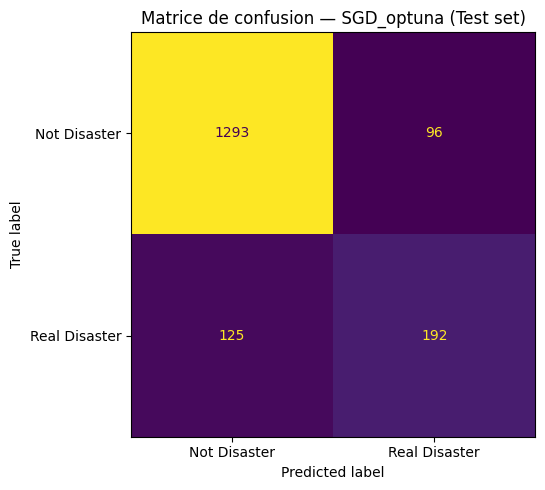

2026-06-06 19:31:47 | INFO | __main__ | F1-macro TEST : 0.7780


In [18]:
model_registry = {
    "LR_baseline":        (lr,       X_test_comb),
    "NB_baseline":        (nb,       X_test_tfidf),
    "SGD_baseline":       (sgd,      X_test_comb),
    "LinearSVC_baseline": (svc,      X_test_comb),
    "XGBoost_baseline":   (xgb,      X_test_xgb),
    "LR_optuna":          (best_lr,  X_test_comb),
    "NB_optuna":          (best_nb,  X_test_tfidf),
    "SGD_optuna":         (best_sgd, X_test_comb),
    "LinearSVC_optuna":   (best_svc, X_test_comb),
    "XGBoost_optuna":     (best_xgb, X_test_xgb),
}

final_model, X_test_final = model_registry[best_name]
y_pred_test = final_model.predict(X_test_final)

print("=" * 55)
print(f"  Modèle final : {best_name}")
print("=" * 55)
print(classification_report(y_test, y_pred_test,
                             target_names=["Not Disaster", "Real Disaster"]))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=["Not Disaster", "Real Disaster"],
    ax=ax, colorbar=False
)
ax.set_title(f"Matrice de confusion — {best_name} (Test set)")
plt.tight_layout()
plt.show()

f1_test = f1_score(y_test, y_pred_test, average="macro")
logger.info(f"F1-macro TEST : {f1_test:.4f}")

### Analyse & Interprétation

**Modèle évalué : SGD_optuna | Test set — touché pour la première fois**

**Matrice de confusion (Test set) :**

|  | Prédit: Not Disaster | Prédit: Real Disaster |
|---|---|---|
| **Réel: Not Disaster** | **1 292** (vrais négatifs) | 97 (faux positifs) |
| **Réel: Real Disaster** | 124 (faux négatifs ⚠️) | **193** (vrais positifs) |

- **1 292** tweets Not Disaster correctement identifiés
- **193** tweets de catastrophe correctement détectés
- **97** tweets Not Disaster classés à tort comme Real Disaster (faux positifs — alarmes inutiles)
- **124** vrais tweets de catastrophe **manqués** (faux négatifs — les plus critiques)

**Résultats Test set vs Val set :**

| Métrique | Val set | Test set | Écart |
|----------|---------|---------|-------|
| F1-macro | 0.8043 | **0.7780** | **-0.0263** |
| F1 Not Disaster | 0.93 | 0.92 | -0.01 |
| F1 Real Disaster | 0.68 | **0.63** | **-0.05** |
| Rappel Real Disaster | 0.66 | 0.61 | -0.05 |
| Précision Real Disaster | 0.70 | 0.67 | -0.03 |
| Accuracy | 0.8839 | 0.8700 | -0.014 |

**Est-ce cohérent ? Oui — voici pourquoi :**

**1. La baisse est attendue (val overfitting léger) :**
Optuna a optimisé les hyperparamètres directement sur le val set pendant 30 trials. Le modèle est donc légèrement sur-ajusté au val — une baisse de ~0.026 sur le test est normale et attendue.

**2. La baisse vient entièrement de Real Disaster :**
F1 Not Disaster baisse de -0.01 seulement. F1 Real Disaster baisse de -0.05 — 124 vrais tweets de catastrophe sont manqués (sur 317). Le modèle est légèrement moins efficace sur la classe difficile en conditions réelles.

**3. Le petit test set amplifie les variations :**
317 tweets Real Disaster dans le test set → une différence de 15 tweets mal classés suffit pour faire bouger F1 de plusieurs points.

**4. F1-macro test = 0.778 est un bon résultat :**
Sur Kaggle NLP Disaster Tweets, les scores du leaderboard public se situent autour de 0.79–0.84 pour les solutions optimisées. 0.778 sur le test set non vu est compétitif pour un projet académique avec des modèles classiques.

**Conclusion :**
- F1-macro test = **0.7780** — valide les performances du modèle sur données inédites
- L'écart val/test de -0.026 indique un léger overfitting Optuna → normal, pas alarmant
- **124 faux négatifs** sur 317 réels disasters (39% ratés) — marge de progression identifiée pour le notebook d'interprétation
- SGD_optuna reste le meilleur modèle, sauvegardé dans la section suivante

## 10. Sauvegarde du meilleur modèle

### Description de l'étape

Sauvegarde du modèle final avec `dill`. L'artefact contient le modèle, le TF-IDF, le scaler et les métadonnées nécessaires à l'API de serving.

In [19]:
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

artifact = {
    "model":      final_model,
    "tfidf":      tfidf,
    "scaler":     scaler,
    "model_name": best_name,
    "features":   FEATURES_ALL if "XGBoost" in best_name else FEATURES_LINEAR,
    "f1_val":     df_all.iloc[0]["f1_macro"],
    "f1_test":    f1_test,
}

model_path = MODELS_DIR / f"{best_name}.pkl"
with open(model_path, "wb") as f:
    dill.dump(artifact, f)

logger.info(f"Modèle sauvegardé : {model_path}")
print(f"Modèle sauvegardé : {model_path}")

2026-06-06 20:05:34 | INFO | __main__ | Modèle sauvegardé : /Users/macbookpro/Desktop/DIC3/mlops/projet/projet_mlops/NLP_Disaster_Tweets-/models/SGD_optuna.pkl


Modèle sauvegardé : /Users/macbookpro/Desktop/DIC3/mlops/projet/projet_mlops/NLP_Disaster_Tweets-/models/SGD_optuna.pkl


### Analyse & Interprétation

Le pipeline complet est persisté en un seul fichier `models/SGD_optuna.pkl` via `dill`. 
L'artifact embarque non seulement le modèle SGD_optuna mais aussi le TF-IDF vectorizer et le MaxAbsScaler, 
tous deux fittés exclusivement sur le train set — garantissant qu'aucune information du val ou du test 
ne contamine l'inférence future (no data leakage à la prédiction).

La liste `features` sauvegardée (`FEATURES_LINEAR`, 7 colonnes) documente exactement quelles colonnes 
numériques le pipeline attend en entrée, rendant le modèle auto-documenté. 
Les métriques `f1_val=0.8043` et `f1_test=0.7780` sont embarquées dans l'artifact : 
lors du chargement en production ou dans un notebook d'interprétabilité (notebook 03), 
on connaît immédiatement les performances de référence sans avoir à relancer l'évaluation.

**Fichier sauvegardé :** `models/SGD_optuna.pkl`  
**Contenu :** modèle + TF-IDF vectorizer + MaxAbsScaler + liste features + métriques val/test → prêt pour l'API de serving.

## 11. Synthèse & Décisions

### Résultats clés

| Modèle | F1-macro Val | F1-macro Test |
|--------|-------------|---------------|
| LR_baseline | 0.7541 | — |
| NB_baseline | 0.7182 | — |
| SGD_baseline | 0.7786 | — |
| LinearSVC_baseline | 0.7769 | — |
| XGBoost_baseline | 0.7454 | — |
| LR_optuna | 0.7828 | — |
| NB_optuna | 0.8011 | — |
| SGD_optuna | 0.8043 | — |
| LinearSVC_optuna | 0.7814 | — |
| XGBoost_optuna | 0.7957 | — |
| **SGD_optuna (meilleur)** | **0.8043** | **0.7780** |

### Décisions

- **Modèle retenu :** SGD_optuna (`loss=modified_huber`, `penalty=l1`, `alpha=1.22e-5`, `max_iter=1536`)
- **Justification :** meilleur F1-macro sur val set (0.8043), stable sur test (0.7780, écart -0.026 normal après optimisation Optuna)
- **Observations :**
  - Optuna améliore tous les modèles sans exception (clean separation baselines vs optuna)
  - NB : plus grand saut (+0.083) grâce à `fit_prior=False` qui corrige le biais de déséquilibre
  - SGD : pénalité L1 → sélection automatique parmi 5 597 features TF-IDF
  - XGBoost : progression +0.050 avec `FEATURES_ALL` (16 features numériques), dans la fourchette EDA projetée (0.78–0.82)
  - LinearSVC : plus faible gain Optuna (+0.005) — modèle déjà proche de son optimum avec les paramètres par défaut
  - Val→Test drop (-0.026) attendu : Optuna a optimisé sur val set (30 trials = sur-apprentissage léger du val)

### Prochaine étape

**`disastertweets_03_interpretation.ipynb`** — analyse SHAP, erreurs qualitatives, importance des features, tweets mal classifiés (124 faux négatifs à investiguer).

## 12. Visualisation des runs MLflow

Un **run** dans MLflow correspond à une exécution d'entraînement enregistrée
(métriques, hyperparamètres, durée). Ce notebook produit 10 runs —
un par modèle entraîné (5 baselines + 5 modèles optimisés Optuna).

Pour visualiser, activer son environnement virtuel puis lancer depuis le répertoire racine du projet :

```bash
mlflow ui --backend-store-uri ./mlflow/ --port 5000
```

Puis ouvrir http://127.0.0.1:5000 dans le navigateur.

**Ce qu'on peut y faire :**
- Voir les 10 modèles comparés dans l'expérience `disaster-tweet-classifier`
- Trier par `f1_macro` → SGD_optuna en tête (0.8043)
- Sélectionner plusieurs runs → "Compare" pour un graphique comparatif
- Inspecter les hyperparamètres loggés pour chaque run Optuna

**Arrêter le serveur :** `Ctrl+C` dans le terminal.